<h1><strong>Unsupervised Learning</strong></h1>

Unsupervised Learning is a type of machine learning where the model is trained on data without labeled outputs.

The goal of the algorithm is to discover hidden patterns, structures, or relationships within the data.


<h3><strong>K-means clustring</strong></h3>

Automatically group data points that are "close" to each other into K number groups

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

In [3]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [14]:
x = iris.data

x

In [15]:
k = 3

In [16]:
kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

In [17]:
model = kmeans.fit(x)

In [18]:
labels = model.labels_

In [19]:
centroids = kmeans.cluster_centers_

In [20]:
centroids

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

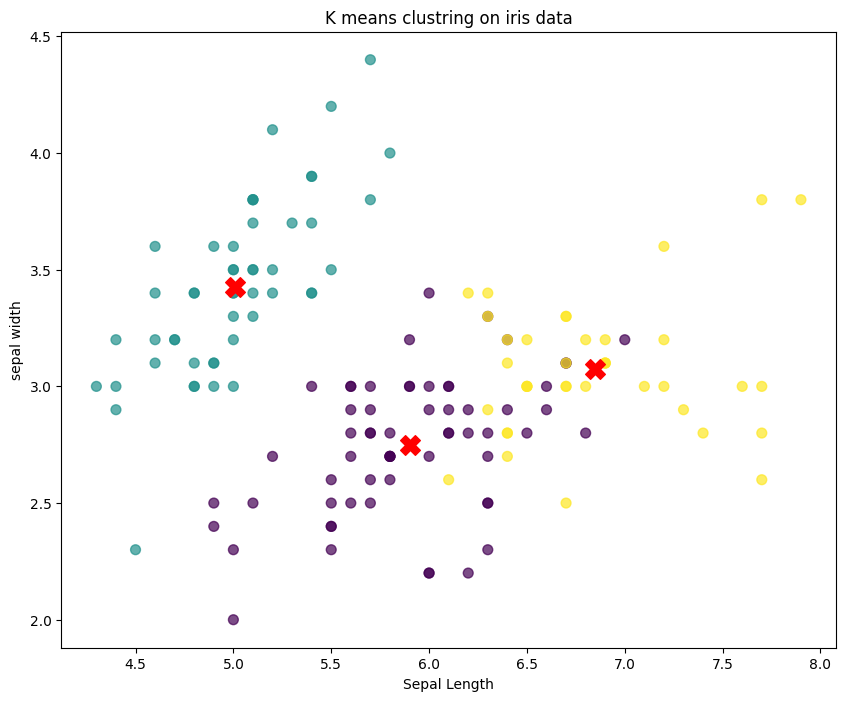

In [21]:
plt.figure(figsize=(10,8))
plt.scatter(x[:,0],x[:,1],c=labels,alpha=0.7,label='data points',s=50)
plt.scatter(centroids[:,0],centroids[:,1],c='red',s=200,marker='X')
plt.title("K means clustring on iris data")
plt.xlabel("Sepal Length")
plt.ylabel("sepal width")
plt.show()

<h3><strong>hierarchical Clustering</strong></h3>

Hierarchical Clustering build a tree like structure (dendrogram) to group data.

Two types:
- Agglomerative(Bottom -> Up) <strong>Most used</strong>
- Divise (Top -> Bottom)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram,linkage

In [23]:
df = pd.DataFrame(load_iris().data,columns=load_iris().feature_names)

In [25]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<strong style="color:green;">Feature Scaling</strong>

In [26]:
scaler = StandardScaler()
x = scaler.fit_transform(df)

<h3>Create dendrogram</h3>

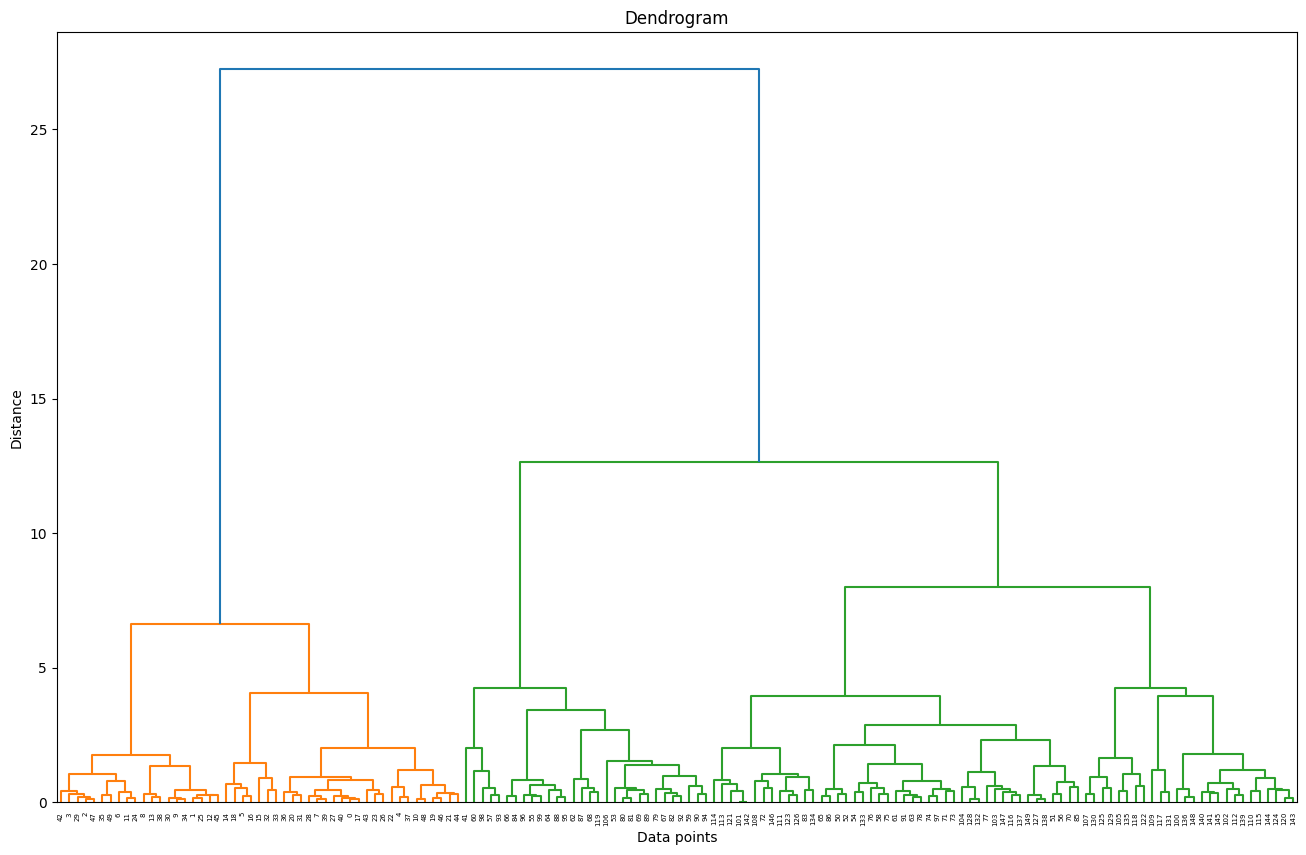

In [33]:
linked = linkage(x,method='ward')

plt.figure(figsize=(16,10))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

In [29]:
model = AgglomerativeClustering(n_clusters=3,linkage='ward')
labels = model.fit_predict(x)

In [30]:
df["Cluster"] = labels

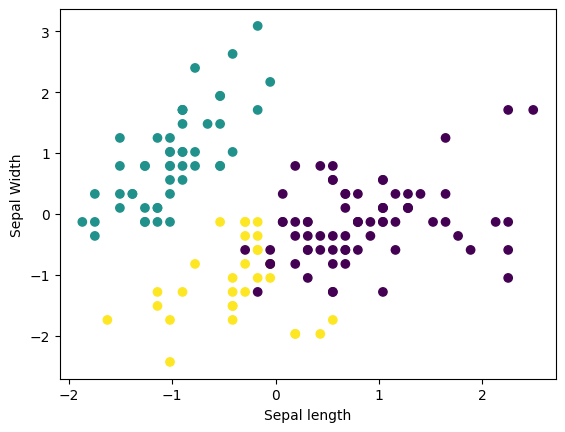

In [32]:
plt.scatter(x[:,0],x[:,1],c=labels)
plt.xlabel("Sepal length")
plt.ylabel("Sepal Width")
plt.show()